# Network — 학교 확산 유형과 관계 지표

## 공통 기준
- 현재 네트워크 스냅샷의 일반 계정(운영·관리 계정 제외)을 사용자 ID로 중복 제거합니다.
- 학교 ID는 현재 스냅샷의 학교입니다. 과거 전학·탈퇴 이력까지 복원한 모집단은 아닙니다.
- D0는 이 모집단의 누적 가입자가 처음 40명에 도달한 날짜입니다. 실제 기능 활성화 로그 시점과 구분합니다.
- 확산 유형은 2023년 4~5월 D0 도달 학교에서 D+1~7, D+8~14 가입자 수의 각각 중앙값으로 분류합니다.
- 최초 가입 후 7·14일과 D0 전후 구간은 서로 다른 시간 기준입니다.
- 유형은 사후 구간으로 분류한 기술 통계입니다. 예측 변수나 인과 효과로 해석하지 않습니다.
- 원본과 동일하게 가입 기록이 없는 학교·일은 0명으로 처리합니다. 추출 범위 밖의 기간을 무가입으로 간주하지 않도록 원본 데이터의 관찰기간을 확인해야 합니다.

## Network 해석 범위
친구 수 등은 현재 스냅샷입니다. 도달 이전에 형성된 관계라고 단정할 수 없습니다.
학교별 사용자 평균을 다시 학교 간 평균 낸 값으로, 전체 사용자를 합친 가중평균과 다릅니다.
요청 수락률은 **해당 구간에 생성된 요청의 최종 수락 상태 비율**이며 구간 내 수락 발생률이 아닙니다.
신규 가입자당 요청 수의 분자는 기존 사용자 요청도 포함하므로 신규 가입자 개인의 요청 수로 해석하지 않습니다.
Clean 마트의 실제 관측 행을 집계하며, 학교·기간별 관측 날짜 수를 함께 확인합니다.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from IPython.display import display

# 기본 구조: 같은 상위 폴더 아래 team7/ 와 team7_marts/
# 다른 위치면 이 한 줄에 실제 폴더 경로를 입력합니다.
DATA_DIR_OVERRIDE = os.environ.get("TEAM7_MARTS_DIR", "")
if DATA_DIR_OVERRIDE:
    data_dir = Path(DATA_DIR_OVERRIDE).expanduser().resolve()
else:
    current = Path.cwd().resolve()
    candidates = []
    for parent in [current, *current.parents]:
        candidates.extend([parent / "team7_marts", parent.parent / "team7_marts"])
    data_dir = next((p for p in candidates if p.is_dir()), None)
    if data_dir is None:
        raise FileNotFoundError("team7_marts 폴더가 없습니다. DATA_DIR_OVERRIDE에 실제 폴더 경로를 입력하세요.")
if not data_dir.is_dir():
    raise FileNotFoundError(f"데이터 폴더가 없습니다: {data_dir}")
print("데이터 폴더:", data_dir)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if font in fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

def read_mart(filename, required):
    path = data_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f"필요한 마트가 없습니다: {path}")
    frame = pd.read_csv(path, low_memory=False, na_values=[r"\N"])
    missing = sorted(set(required) - set(frame.columns))
    if missing:
        raise ValueError(f"{filename}: 필수 컬럼 누락 {missing}")
    return frame

network = read_mart("mart_user_network_snapshot.csv", [
    "user_id", "school_id", "user_created_at", "is_staff", "is_superuser"
])
for column in ["is_staff", "is_superuser"]:
    network[column] = pd.to_numeric(network[column], errors="coerce")

데이터 폴더: /Users/jangjunyoung/DA15_Part4/team7_marts


In [2]:
# ============================================================
# 2. 분석용 사용자 데이터 정리
# ============================================================

users = network.copy()

# 관리자·운영 계정 제외
users = users[
    users["is_superuser"].fillna(0).eq(0)
    & users["is_staff"].fillna(0).eq(0)
].copy()

# 자료형 변환
users["school_id"] = pd.to_numeric(
    users["school_id"],
    errors="coerce"
)

users["user_id"] = pd.to_numeric(
    users["user_id"],
    errors="coerce"
)

users["user_created_at"] = pd.to_datetime(
    users["user_created_at"],
    errors="coerce"
)

# 분석 필수값이 없는 행 제외
users = users.dropna(
    subset=["user_id", "school_id", "user_created_at"]
).copy()

users["user_id"] = users["user_id"].astype("int64")
users["school_id"] = users["school_id"].astype("int64")
users["signup_date"] = users["user_created_at"].dt.normalize()
users["signup_month"] = (
    users["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

# 사용자 중복 제거
users = (
    users
    .sort_values("user_created_at")
    .drop_duplicates("user_id", keep="first")
    .reset_index(drop=True)
)

print("분석 사용자 수:", f"{users['user_id'].nunique():,}명")
print("분석 학교 수:", f"{users['school_id'].nunique():,}개")
print(
    "가입일 범위:",
    users["signup_date"].min(),
    "~",
    users["signup_date"].max()
)

display(users.head())

분석 사용자 수: 677,080명
분석 학교 수: 5,551개
가입일 범위: 2023-03-29 00:00:00 ~ 2024-05-09 00:00:00


,mart_built_at,user_id,gender,user_created_at,is_superuser,is_staff,ban_status,group_id,grade,class_num,school_id,school_address,school_type,student_count,current_friend_count_snapshot,network_degree_count,mutual_friend_count,one_way_friend_count,valid_outbound_listing_count,valid_inbound_listing_count,same_school_friend_count,same_grade_friend_count,same_group_friend_count,unknown_school_relation_count,orphan_friend_reference_count,duplicate_friend_reference_count,is_isolated_current_snapshot,is_isolated_valid_network,is_inbound_only_user,reciprocity_rate,same_school_friend_rate,same_group_friend_rate,degree_centrality,sent_request_count,sent_accepted_count,sent_pending_count,sent_rejected_count,received_request_count,received_accepted_count,received_pending_count,received_rejected_count,total_request_activity_count,accepted_request_record_count,pending_request_record_count,rejected_request_record_count,accepted_request_partner_count,has_accepted_request_partner,repeated_accepted_request_count,sent_acceptance_rate,received_acceptance_rate,sent_decision_acceptance_rate,received_decision_acceptance_rate,network_status,request_status,signup_date,signup_month
0,2026-09-02 00:47:38.728474,831962,F,2023-03-29 05:18:56.162368,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,43,31,31,0,31,31,25,2,0,0,12,0,0,0,0,1.00,0.81,0.00,0.00,1,1,0,0,26,0,26,0,27,1,26,0,1,1,0,1.00,0.00,1.00,NaN,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
1,2026-09-02 00:47:38.728474,832151,M,2023-03-29 12:56:34.989468,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,51,50,50,0,50,50,45,35,32,0,1,0,0,0,0,1.00,0.90,0.64,0.00,10,2,8,0,35,6,29,0,45,8,37,0,8,1,0,0.20,0.17,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
2,2026-09-02 00:47:38.728474,832340,F,2023-03-29 12:56:35.020790,0,0,N,1.00,1.00,1.00,1,NaN,NaN,NaN,57,56,56,0,56,56,51,36,32,0,1,0,0,0,0,1.00,0.91,0.57,0.00,26,7,19,0,25,4,21,0,51,11,40,0,11,1,0,0.27,0.16,1.00,1.00,FULLY_RECIPROCAL,HAS_ACCEPTED_PARTNER,2023-03-29,2023-03
3,2026-09-02 00:47:38.728474,832520,M,2023-03-29 12:56:35.049311,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,18,17,17,0,17,17,12,3,2,0,1,0,0,0,0,1.00,0.71,0.12,0.00,0,0,0,0,14,0,14,0,14,0,14,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03
4,2026-09-02 00:47:38.728474,832614,M,2023-03-29 12:56:35.064406,0,0,N,12.00,2.00,1.00,1,NaN,NaN,NaN,21,20,20,0,20,20,16,6,4,0,1,0,0,0,0,1.00,0.80,0.20,0.00,0,0,0,0,12,0,12,0,12,0,12,0,0,0,0,NaN,0.00,NaN,NaN,FULLY_RECIPROCAL,REQUEST_WITHOUT_ACCEPTED_PARTNER,2023-03-29,2023-03


## 학교 ID·D0·확산 유형 독립 생성

In [3]:
# ============================================================
# 4. 학교별 40명 도달 여부 및 도달일 계산
# ============================================================

# 학교별 일별 신규 가입자
school_daily_signup = (
    users
    .groupby(["school_id", "signup_date"])["user_id"]
    .nunique()
    .rename("일별가입자수")
    .reset_index()
    .sort_values(["school_id", "signup_date"])
)

# 학교별 누적 가입자
school_daily_signup["누적가입자수"] = (
    school_daily_signup
    .groupby("school_id")["일별가입자수"]
    .cumsum()
)

# 학교별 최초 가입일
school_first_signup = (
    school_daily_signup
    .groupby("school_id")["signup_date"]
    .min()
    .rename("최초가입일")
    .reset_index()
)

# 학교별 40명 최초 도달일
school_reach_40 = (
    school_daily_signup[
        school_daily_signup["누적가입자수"] >= 40
    ]
    .groupby("school_id")["signup_date"]
    .min()
    .rename("40명_도달일")
    .reset_index()
)

# 학교별 최종 가입자 수
school_final_users = (
    users
    .groupby("school_id")["user_id"]
    .nunique()
    .rename("최종가입자수")
    .reset_index()
)

# 학교 단위 데이터 결합
school_activation = (
    school_first_signup
    .merge(
        school_reach_40,
        on="school_id",
        how="left"
    )
    .merge(
        school_final_users,
        on="school_id",
        how="left"
    )
)

school_activation["40명_도달여부"] = np.where(
    school_activation["40명_도달일"].notna(),
    "40명 도달",
    "40명 미도달"
)

school_activation["40명_도달소요일"] = (
    school_activation["40명_도달일"]
    - school_activation["최초가입일"]
).dt.days + 1

print("전체 학교 수:", f"{school_activation['school_id'].nunique():,}개")

display(
    school_activation["40명_도달여부"]
    .value_counts()
    .rename_axis("도달구분")
    .reset_index(name="학교수")
)

display(school_activation.head())

전체 학교 수: 5,551개


,도달구분,학교수
0,40명 도달,3897
1,40명 미도달,1654


,school_id,최초가입일,40명_도달일,최종가입자수,40명_도달여부,40명_도달소요일
0,1,2023-03-29,2023-04-29,93,40명 도달,32.00
1,4,2023-05-08,2023-05-12,235,40명 도달,5.00
2,5,2023-05-07,2023-05-13,160,40명 도달,7.00
3,6,2023-05-01,2023-05-12,197,40명 도달,12.00
4,7,2023-04-23,2023-05-13,114,40명 도달,21.00


In [4]:
# ============================================================
# 6. 40명 도달일(D0) 기준 상대 일자 생성
# ============================================================

# 2023년 4~5월에 40명에 도달한 학교만 선택
viral_reached_schools = school_activation[
    school_activation["40명_도달일"].between(
        pd.Timestamp("2023-04-01"),
        pd.Timestamp("2023-05-31")
    )
][
    ["school_id", "40명_도달일"]
].copy()

print(
    "4~5월 40명 도달 학교:",
    f"{viral_reached_schools['school_id'].nunique():,}개"
)

# 학교별 일별 가입 데이터에 D0 결합
event_signup = school_daily_signup.merge(
    viral_reached_schools,
    on="school_id",
    how="inner"
)

# D0 기준 상대 일자
event_signup["relative_day"] = (
    event_signup["signup_date"]
    - event_signup["40명_도달일"]
).dt.days

# D-14부터 D+14까지만 사용
event_signup = event_signup[
    event_signup["relative_day"].between(-14, 14)
].copy()

display(event_signup.head())

4~5월 40명 도달 학교: 3,796개


,school_id,signup_date,일별가입자수,누적가입자수,40명_도달일,relative_day
3,1,2023-04-15,3,18,2023-04-29,-14
4,1,2023-04-17,2,20,2023-04-29,-12
5,1,2023-04-19,2,22,2023-04-29,-10
6,1,2023-04-20,1,23,2023-04-29,-9
7,1,2023-04-21,1,24,2023-04-29,-8


In [5]:
# ============================================================
# 6-1. 학교별 D-14~D+14 날짜 균형 맞추기
# ============================================================

school_ids = viral_reached_schools["school_id"].unique()
relative_days = np.arange(-14, 15)

# 모든 학교 × 29일 조합 생성
balanced_school_day = pd.MultiIndex.from_product(
    [school_ids, relative_days],
    names=["school_id", "relative_day"]
).to_frame(index=False)

# 실제 가입자 수 결합
balanced_school_day = balanced_school_day.merge(
    event_signup[
        ["school_id", "relative_day", "일별가입자수"]
    ],
    on=["school_id", "relative_day"],
    how="left"
)

# 가입 기록이 없는 날짜는 0명
balanced_school_day["일별가입자수"] = (
    balanced_school_day["일별가입자수"]
    .fillna(0)
)

print(
    "분석 학교 수:",
    f"{balanced_school_day['school_id'].nunique():,}개"
)

print(
    "학교·일 데이터 수:",
    f"{len(balanced_school_day):,}행"
)

display(balanced_school_day.head())

분석 학교 수: 3,796개
학교·일 데이터 수: 110,084행


,school_id,relative_day,일별가입자수
0,1,-14,3.00
1,1,-13,0.00
2,1,-12,2.00
3,1,-11,0.00
4,1,-10,2.00


In [6]:
# ============================================================
# 7. D0를 제외한 네 구간 설정
# ============================================================

def classify_period(relative_day):
    if -14 <= relative_day <= -8:
        return "도달 이전 D-14~-8"

    if -7 <= relative_day <= -1:
        return "도달 직전 D-7~-1"

    if 1 <= relative_day <= 7:
        return "도달 직후 D+1~+7"

    if 8 <= relative_day <= 14:
        return "도달 후기 D+8~+14"

    return np.nan


period_order = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14"
]

# D0 제외
period_data = balanced_school_day[
    balanced_school_day["relative_day"] != 0
].copy()

period_data["기간"] = period_data["relative_day"].apply(
    classify_period
)

period_data["기간"] = pd.Categorical(
    period_data["기간"],
    categories=period_order,
    ordered=True
)

display(period_data.head())

,school_id,relative_day,일별가입자수,기간
0,1,-14,3.00,도달 이전 D-14~-8
1,1,-13,0.00,도달 이전 D-14~-8
2,1,-12,2.00,도달 이전 D-14~-8
3,1,-11,0.00,도달 이전 D-14~-8
4,1,-10,2.00,도달 이전 D-14~-8


In [7]:
# ============================================================
# 7-1. 학교별 네 구간 가입자 집계
# ============================================================

school_period_summary = (
    period_data
    .groupby(
        ["school_id", "기간"],
        observed=True
    )
    .agg(
        구간추가가입자=("일별가입자수", "sum"),
        일평균가입자=("일별가입자수", "mean"),
        가입발생일수=(
            "일별가입자수",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

display(school_period_summary.head(12))

,school_id,기간,구간추가가입자,일평균가입자,가입발생일수
0,1,도달 이전 D-14~-8,9.00,1.29,5
1,1,도달 직전 D-7~-1,14.00,2.00,5
2,1,도달 직후 D+1~+7,7.00,1.00,3
3,1,도달 후기 D+8~+14,7.00,1.00,5
4,4,도달 이전 D-14~-8,0.00,0.00,0
5,4,도달 직전 D-7~-1,15.00,2.14,3
6,4,도달 직후 D+1~+7,169.00,24.14,7
7,4,도달 후기 D+8~+14,4.00,0.57,3
8,5,도달 이전 D-14~-8,0.00,0.00,0
9,5,도달 직전 D-7~-1,19.00,2.71,5


In [8]:
# ============================================================
# 8. 학교별 네 구간 가입자 데이터를 가로 형태로 변환
# ============================================================

school_diffusion = (
    school_period_summary
    .pivot(
        index="school_id",
        columns="기간",
        values="구간추가가입자"
    )
    .reset_index()
)

school_diffusion.columns.name = None

school_diffusion = school_diffusion.rename(
    columns={
        "도달 이전 D-14~-8": "도달이전_D14_D8",
        "도달 직전 D-7~-1": "도달직전_D7_D1",
        "도달 직후 D+1~+7": "첫째주_D1_D7",
        "도달 후기 D+8~+14": "둘째주_D8_D14"
    }
)

period_columns = [
    "도달이전_D14_D8",
    "도달직전_D7_D1",
    "첫째주_D1_D7",
    "둘째주_D8_D14"
]

school_diffusion[period_columns] = (
    school_diffusion[period_columns]
    .fillna(0)
)

# 도달 소요일과 최종 가입자 수 결합
school_diffusion = school_diffusion.merge(
    school_activation[
        [
            "school_id",
            "40명_도달소요일",
            "최종가입자수"
        ]
    ],
    on="school_id",
    how="left"
)

display(school_diffusion.head())

,school_id,도달이전_D14_D8,도달직전_D7_D1,첫째주_D1_D7,둘째주_D8_D14,40명_도달소요일,최종가입자수
0,1,9.00,14.00,7.00,7.00,32.00,93
1,4,0.00,15.00,169.00,4.00,5.00,235
2,5,0.00,19.00,65.00,2.00,7.00,160
3,6,2.00,21.00,132.00,9.00,12.00,197
4,7,1.00,5.00,55.00,4.00,21.00,114


In [9]:
# ============================================================
# 8-1. 네 가지 확산 유형 분류
# ============================================================

# 도달 후 첫째 주와 둘째 주 중앙값
first_week_median = school_diffusion[
    "첫째주_D1_D7"
].median()

second_week_median = school_diffusion[
    "둘째주_D8_D14"
].median()

conditions = [
    # 첫째 주와 둘째 주 모두 기준 이상
    (
        school_diffusion["첫째주_D1_D7"] >= first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] >= second_week_median
    ),

    # 첫째 주는 높지만 둘째 주는 낮음
    (
        school_diffusion["첫째주_D1_D7"] >= first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] < second_week_median
    ),

    # 첫째 주는 낮지만 둘째 주는 높음
    (
        school_diffusion["첫째주_D1_D7"] < first_week_median
    )
    & (
        school_diffusion["둘째주_D8_D14"] >= second_week_median
    )
]

choices = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형"
]

school_diffusion["확산유형"] = np.select(
    conditions,
    choices,
    default="저확산형"
)

print("첫째 주 분류 기준:", first_week_median)
print("둘째 주 분류 기준:", second_week_median)

type_count = (
    school_diffusion["확산유형"]
    .value_counts()
    .rename_axis("확산유형")
    .reset_index(name="학교수")
)

type_count["학교비율(%)"] = (
    type_count["학교수"]
    / type_count["학교수"].sum()
    * 100
).round(2)

display(type_count)

첫째 주 분류 기준: 76.0
둘째 주 분류 기준: 8.0


,확산유형,학교수,학교비율(%)
0,지속 확산형,1382,36.41
1,저확산형,1288,33.93
2,후발 확산형,586,15.44
3,단기 폭발형,540,14.23


# 학교별 친구 네트워크 지표 생성

In [10]:
# ============================================================
# 9. 학교별 친구 네트워크 지표 생성
# ============================================================

friend_columns = [
    "current_friend_count_snapshot",
    "same_school_friend_count",
    "same_school_friend_rate",
    "sent_request_count",
    "received_request_count",
    "total_request_activity_count",
    "accepted_request_record_count",
    "has_accepted_request_partner"
]

# 필요한 컬럼 존재 여부 확인
missing_friend_columns = [
    column
    for column in friend_columns
    if column not in users.columns
]

if missing_friend_columns:
    raise ValueError(
        f"친구 네트워크 컬럼이 없습니다: {missing_friend_columns}"
    )

# 숫자형 변환
for column in friend_columns:
    users[column] = pd.to_numeric(
        users[column],
        errors="coerce"
    )

# 사용자 데이터를 학교 단위 평균으로 집계
school_friend_summary = (
    users
    .groupby("school_id")
    .agg(
        학교평균친구수=(
            "current_friend_count_snapshot",
            "mean"
        ),
        동일학교친구수_평균=(
            "same_school_friend_count",
            "mean"
        ),
        동일학교친구비율_평균=(
            "same_school_friend_rate",
            "mean"
        ),
        발송요청수_평균=(
            "sent_request_count",
            "mean"
        ),
        수신요청수_평균=(
            "received_request_count",
            "mean"
        ),
        전체요청활동수_평균=(
            "total_request_activity_count",
            "mean"
        ),
        수락요청수_평균=(
            "accepted_request_record_count",
            "mean"
        ),
        요청수락경험률_평균=(
            "has_accepted_request_partner",
            "mean"
        )
    )
    .reset_index()
)

# 0~1 비율을 백분율로 변환
school_friend_summary["동일학교친구비율_평균"] *= 100
school_friend_summary["요청수락경험률_평균"] *= 100

display(school_friend_summary.head())

,school_id,학교평균친구수,동일학교친구수_평균,동일학교친구비율_평균,발송요청수_평균,수신요청수_평균,전체요청활동수_평균,수락요청수_평균,요청수락경험률_평균
0,1,23.82,18.56,80.90,9.65,11.57,21.22,3.09,67.74
1,4,43.31,27.89,65.87,17.96,19.17,37.13,30.47,96.60
2,5,53.01,45.91,86.67,25.00,24.66,49.66,35.98,99.38
3,6,47.83,30.84,63.19,22.17,19.71,41.87,36.42,94.92
4,7,45.42,26.70,63.28,21.25,16.73,37.98,25.45,95.61


# 40명 도달 여부별 친구 네트워크 비교

In [11]:
# ============================================================
# 9-1. 40명 도달 여부별 친구 네트워크 비교
# ============================================================

reach_friend = school_activation[
    ["school_id", "40명_도달여부"]
].merge(
    school_friend_summary,
    on="school_id",
    how="left"
)

reach_friend_summary = (
    reach_friend
    .groupby("40명_도달여부")
    .agg(
        학교수=("school_id", "nunique"),
        학교평균친구수_평균=("학교평균친구수", "mean"),
        학교평균친구수_중앙값=("학교평균친구수", "median"),
        동일학교친구수_평균=("동일학교친구수_평균", "mean"),
        동일학교친구비율_평균=("동일학교친구비율_평균", "mean"),
        발송요청수_평균=("발송요청수_평균", "mean"),
        수신요청수_평균=("수신요청수_평균", "mean"),
        전체요청활동수_평균=("전체요청활동수_평균", "mean"),
        수락요청수_평균=("수락요청수_평균", "mean"),
        요청수락경험률_평균=("요청수락경험률_평균", "mean")
    )
    .reset_index()
)

numeric_columns = reach_friend_summary.select_dtypes(
    include="number"
).columns

reach_friend_summary[numeric_columns] = (
    reach_friend_summary[numeric_columns]
    .round(2)
)

display(reach_friend_summary)

,40명_도달여부,학교수,학교평균친구수_평균,학교평균친구수_중앙값,동일학교친구수_평균,동일학교친구비율_평균,발송요청수_평균,수신요청수_평균,전체요청활동수_평균,수락요청수_평균,요청수락경험률_평균
0,40명 도달,3897,51.68,51.85,38.44,74.46,24.95,24.31,49.26,36.51,96.29
1,40명 미도달,1654,12.79,10.31,5.07,45.46,7.45,5.03,12.48,6.31,62.55


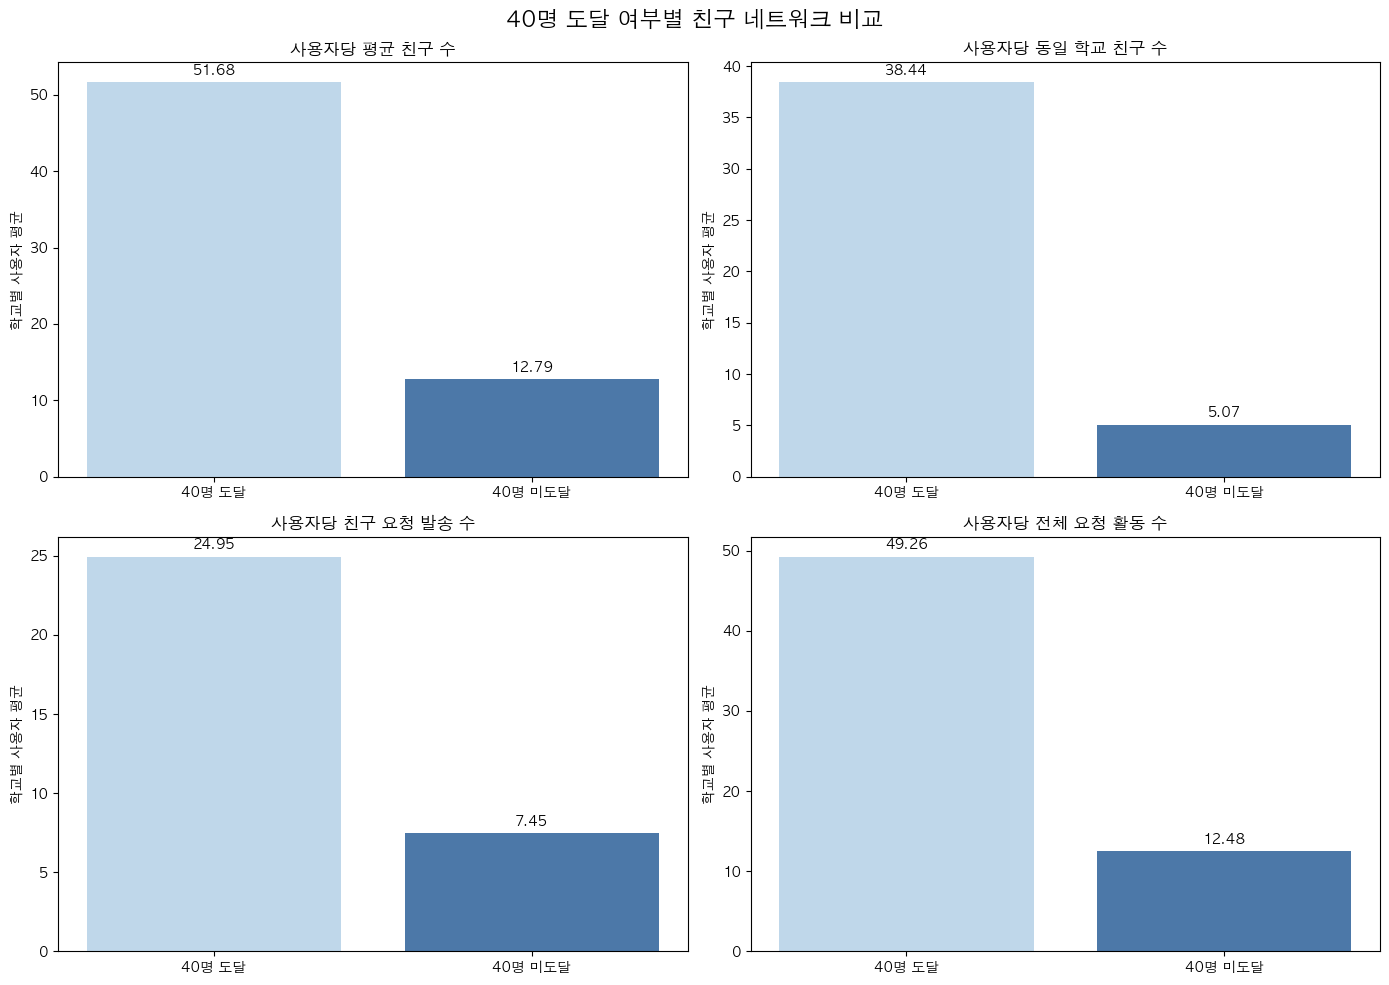

In [12]:
# ============================================================
# 9-2. 40명 도달 여부별 친구 네트워크 시각화
# ============================================================

plot_columns = [
    ("학교평균친구수_평균", "사용자당 평균 친구 수"),
    ("동일학교친구수_평균", "사용자당 동일 학교 친구 수"),
    ("발송요청수_평균", "사용자당 친구 요청 발송 수"),
    ("전체요청활동수_평균", "사용자당 전체 요청 활동 수")
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

for ax, (column, title) in zip(
    axes.flatten(),
    plot_columns
):
    bars = ax.bar(
        reach_friend_summary["40명_도달여부"],
        reach_friend_summary[column],
        color=["#BFD7EA", "#4C78A8"]
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("학교별 사용자 평균")

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

plt.suptitle(
    "40명 도달 여부별 친구 네트워크 비교",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 네 가지 확산 유형과 친구 네트워크 지표 결합해 유형별 차이를 비교

In [13]:
# ============================================================
# 10. 확산 유형과 친구 네트워크 지표 결합
# ============================================================

diffusion_friend = school_diffusion[
    [
        "school_id",
        "확산유형",
        "도달이전_D14_D8",
        "도달직전_D7_D1",
        "첫째주_D1_D7",
        "둘째주_D8_D14",
        "40명_도달소요일",
        "최종가입자수"
    ]
].merge(
    school_friend_summary,
    on="school_id",
    how="left",
    validate="one_to_one"
)

print(
    "결합된 학교 수:",
    f"{diffusion_friend['school_id'].nunique():,}개"
)

print(
    "친구 지표가 없는 학교:",
    f"{diffusion_friend['학교평균친구수'].isna().sum():,}개"
)

display(diffusion_friend.head())

결합된 학교 수: 3,796개
친구 지표가 없는 학교: 0개


,school_id,확산유형,도달이전_D14_D8,도달직전_D7_D1,첫째주_D1_D7,둘째주_D8_D14,40명_도달소요일,최종가입자수,학교평균친구수,동일학교친구수_평균,동일학교친구비율_평균,발송요청수_평균,수신요청수_평균,전체요청활동수_평균,수락요청수_평균,요청수락경험률_평균
0,1,저확산형,9.00,14.00,7.00,7.00,32.00,93,23.82,18.56,80.90,9.65,11.57,21.22,3.09,67.74
1,4,단기 폭발형,0.00,15.00,169.00,4.00,5.00,235,43.31,27.89,65.87,17.96,19.17,37.13,30.47,96.60
2,5,저확산형,0.00,19.00,65.00,2.00,7.00,160,53.01,45.91,86.67,25.00,24.66,49.66,35.98,99.38
3,6,지속 확산형,2.00,21.00,132.00,9.00,12.00,197,47.83,30.84,63.19,22.17,19.71,41.87,36.42,94.92
4,7,저확산형,1.00,5.00,55.00,4.00,21.00,114,45.42,26.70,63.28,21.25,16.73,37.98,25.45,95.61


In [14]:
# ============================================================
# 10-1. 확산 유형별 친구 네트워크 요약
# ============================================================

diffusion_friend_summary = (
    diffusion_friend
    .groupby("확산유형")
    .agg(
        학교수=("school_id", "nunique"),

        사용자당_평균친구수=(
            "학교평균친구수",
            "mean"
        ),

        사용자당_동일학교친구수=(
            "동일학교친구수_평균",
            "mean"
        ),

        동일학교친구비율=(
            "동일학교친구비율_평균",
            "mean"
        ),

        사용자당_발송요청수=(
            "발송요청수_평균",
            "mean"
        ),

        사용자당_수신요청수=(
            "수신요청수_평균",
            "mean"
        ),

        사용자당_전체요청활동수=(
            "전체요청활동수_평균",
            "mean"
        ),

        사용자당_수락요청수=(
            "수락요청수_평균",
            "mean"
        ),

        요청수락경험률=(
            "요청수락경험률_평균",
            "mean"
        ),

        도달소요일_중앙값=(
            "40명_도달소요일",
            "median"
        ),

        최종가입자수_중앙값=(
            "최종가입자수",
            "median"
        )
    )
    .reset_index()
)

type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형"
]

diffusion_friend_summary["확산유형"] = pd.Categorical(
    diffusion_friend_summary["확산유형"],
    categories=type_order,
    ordered=True
)

diffusion_friend_summary = (
    diffusion_friend_summary
    .sort_values("확산유형")
    .reset_index(drop=True)
)

numeric_columns = diffusion_friend_summary.select_dtypes(
    include="number"
).columns

diffusion_friend_summary[numeric_columns] = (
    diffusion_friend_summary[numeric_columns]
    .round(2)
)

display(diffusion_friend_summary)

,확산유형,학교수,사용자당_평균친구수,사용자당_동일학교친구수,동일학교친구비율,사용자당_발송요청수,사용자당_수신요청수,사용자당_전체요청활동수,사용자당_수락요청수,요청수락경험률,도달소요일_중앙값,최종가입자수_중앙값
0,지속 확산형,1382,55.76,42.94,76.48,25.98,26.60,52.58,40.07,97.10,8.00,235.00
1,단기 폭발형,540,59.01,45.29,76.57,28.22,28.45,56.67,43.39,97.39,9.00,185.00
2,후발 확산형,586,48.10,33.93,70.94,23.07,22.15,45.22,32.75,95.75,8.00,124.00
3,저확산형,1288,46.86,33.74,73.27,23.54,21.63,45.17,32.11,95.32,11.00,91.00


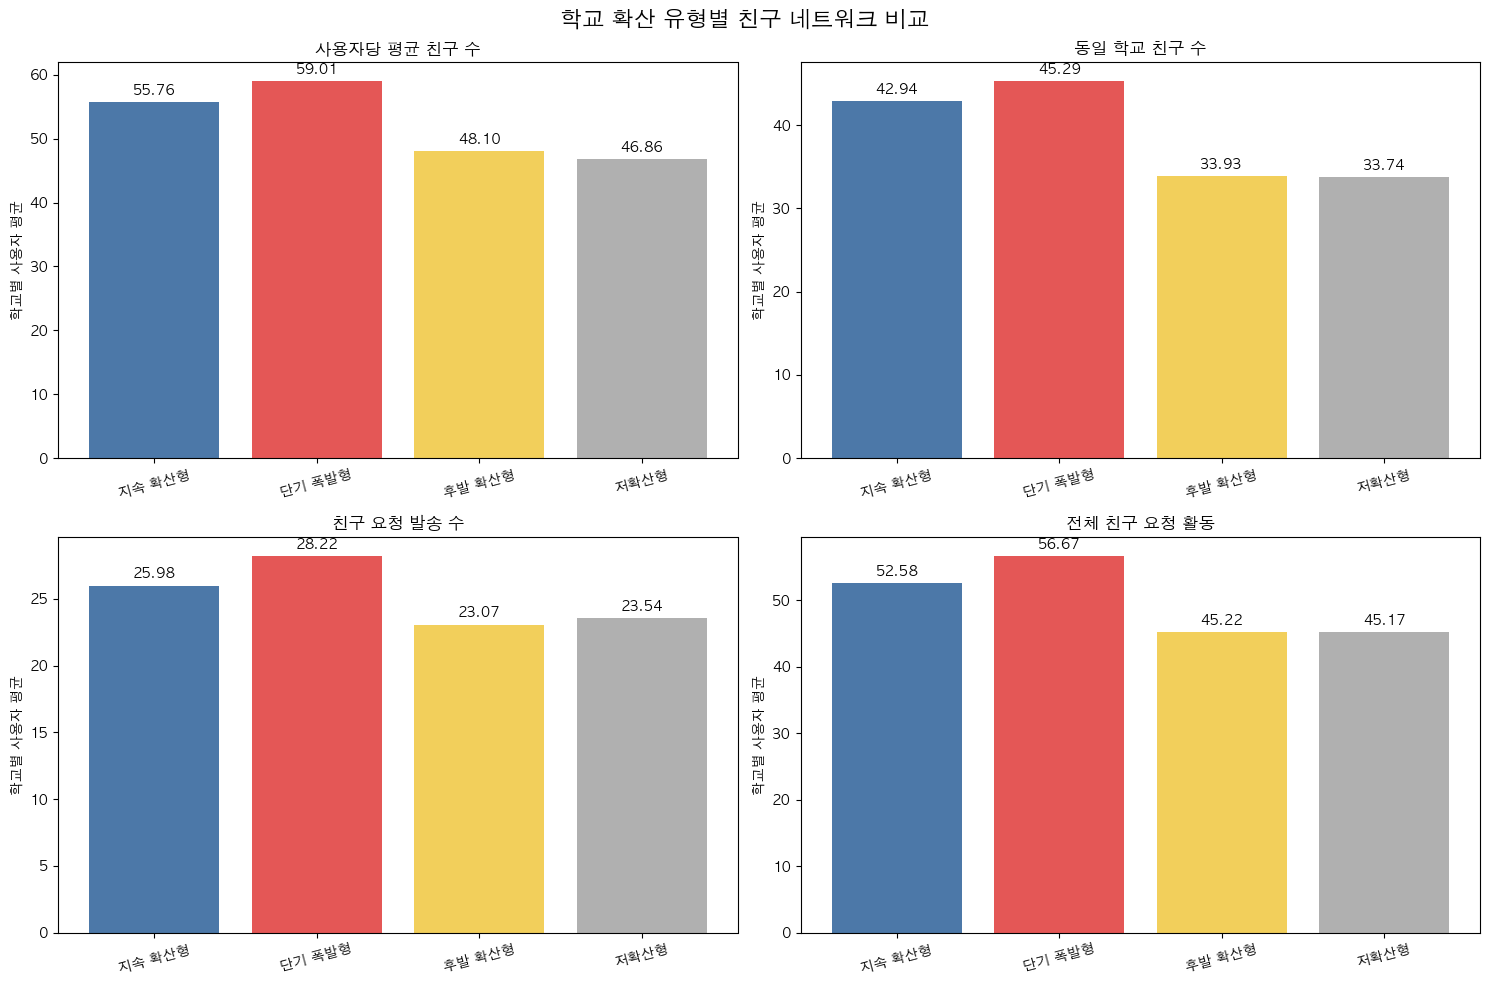

In [15]:
# ============================================================
# 10-2. 확산 유형별 친구 네트워크 시각화
# ============================================================

plot_columns = [
    ("사용자당_평균친구수", "사용자당 평균 친구 수"),
    ("사용자당_동일학교친구수", "동일 학교 친구 수"),
    ("사용자당_발송요청수", "친구 요청 발송 수"),
    ("사용자당_전체요청활동수", "전체 친구 요청 활동")
]

colors = [
    "#4C78A8",
    "#E45756",
    "#F2CF5B",
    "#B0B0B0"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10)
)

for ax, (column, title) in zip(
    axes.flatten(),
    plot_columns
):
    bars = ax.bar(
        diffusion_friend_summary["확산유형"].astype(str),
        diffusion_friend_summary[column],
        color=colors
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("학교별 사용자 평균")
    ax.tick_params(axis="x", rotation=15)

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

plt.suptitle(
    "학교 확산 유형별 친구 네트워크 비교",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Clean 마트 기반 요청 생성 구간 비교

In [16]:
school_viral_clean = read_mart("mart_school_viral_daily_v2_clean.csv.gz", [
    "school_id", "activity_date", "current_roster_40th_signup_at",
    "sent_request_created_count", "sent_created_final_accepted_count",
    "sent_request_user_count", "new_nonstaff_account_count_current_roster"
])
school_viral_clean["school_id"] = pd.to_numeric(school_viral_clean["school_id"], errors="coerce")
school_viral_clean["activity_date"] = pd.to_datetime(school_viral_clean["activity_date"], errors="coerce").dt.normalize()
school_viral_clean["current_roster_40th_signup_at"] = pd.to_datetime(
    school_viral_clean["current_roster_40th_signup_at"], errors="coerce").dt.normalize()
school_viral_clean = school_viral_clean.dropna(subset=["school_id", "activity_date"]).copy()
if school_viral_clean.duplicated(["school_id", "activity_date"]).any():
    raise ValueError("Clean 학교 마트에 학교·날짜 중복이 있습니다. 집계 전 확인하세요.")
canonical_school_map = school_diffusion[["school_id", "확산유형"]].merge(
    school_activation[["school_id", "40명_도달일"]], on="school_id", validate="one_to_one"
).rename(columns={"40명_도달일": "D0"})
school_viral_type_clean = school_viral_clean.merge(
    canonical_school_map, on="school_id", how="inner", validate="many_to_one")
d0_check = school_viral_type_clean[["school_id", "D0", "current_roster_40th_signup_at"]].drop_duplicates()
d0_mismatch = d0_check[d0_check["current_roster_40th_signup_at"].notna()
                       & d0_check["D0"].ne(d0_check["current_roster_40th_signup_at"])]
print("D0가 Clean 마트와 다른 학교 수:", d0_mismatch["school_id"].nunique())
if not d0_mismatch.empty:
    display(d0_mismatch.head(20))
print("이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.")
school_viral_type_clean["relative_day"] = (
    school_viral_type_clean["activity_date"] - school_viral_type_clean["D0"]).dt.days
school_viral_type_clean = school_viral_type_clean[
    school_viral_type_clean["relative_day"].between(-14, 14)].copy()
for col in ["sent_request_created_count", "sent_created_final_accepted_count",
            "sent_request_user_count", "new_nonstaff_account_count_current_roster"]:
    school_viral_type_clean[col] = pd.to_numeric(school_viral_type_clean[col], errors="raise")
print("Clean 마트 결합 학교 수:", school_viral_type_clean["school_id"].nunique())

D0가 Clean 마트와 다른 학교 수: 0
이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.
Clean 마트 결합 학교 수: 3795


In [17]:
# ============================================================
# 14-3. D0를 제외한 네 구간 설정
# ============================================================

def classify_clean_period(relative_day):
    if -14 <= relative_day <= -8:
        return "도달 이전 D-14~-8"
    elif -7 <= relative_day <= -1:
        return "도달 직전 D-7~-1"
    elif 1 <= relative_day <= 7:
        return "도달 직후 D+1~+7"
    elif 8 <= relative_day <= 14:
        return "도달 후기 D+8~+14"
    return np.nan


clean_period_order = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14"
]

request_period_clean = school_viral_type_clean[
    school_viral_type_clean["relative_day"].ne(0)
].copy()

request_period_clean["기간"] = (
    request_period_clean["relative_day"]
    .apply(classify_clean_period)
)

request_period_clean = request_period_clean[
    request_period_clean["기간"].notna()
].copy()

request_period_clean["기간"] = pd.Categorical(
    request_period_clean["기간"],
    categories=clean_period_order,
    ordered=True
)

print(
    "최종 분석 학교 수:",
    f"{request_period_clean['school_id'].nunique():,}개"
)

display(
    request_period_clean[
        [
            "school_id",
            "확산유형",
            "relative_day",
            "기간",
            "sent_request_created_count",
            "sent_created_final_accepted_count"
        ]
    ].head()
)

최종 분석 학교 수: 3,795개


,school_id,확산유형,relative_day,기간,sent_request_created_count,sent_created_final_accepted_count
30,4,단기 폭발형,-14,도달 이전 D-14~-8,0,0
31,4,단기 폭발형,-13,도달 이전 D-14~-8,0,0
32,4,단기 폭발형,-12,도달 이전 D-14~-8,0,0
33,4,단기 폭발형,-11,도달 이전 D-14~-8,0,0
34,4,단기 폭발형,-10,도달 이전 D-14~-8,0,0


In [18]:
request_observed_days = request_period_clean.groupby(
    ["school_id", "확산유형", "기간"], observed=True
)["activity_date"].nunique().reset_index(name="관측날짜수")
print("학교·기간당 관측날짜 수 분포(완전한 구간은 7일):")
display(request_observed_days["관측날짜수"].value_counts().sort_index())

학교·기간당 관측날짜 수 분포(완전한 구간은 7일):


관측날짜수
7    15180
Name: count, dtype: int64

# 학교·구간별 친구 요청 지표 계산

In [19]:
# ============================================================
# 14-4. 학교·구간별 친구 요청 지표 계산
# ============================================================

school_request_period_clean = (
    request_period_clean
    .groupby(
        ["school_id", "확산유형", "기간"],
        observed=True
    )
    .agg(
        신규가입자수=(
            "new_nonstaff_account_count_current_roster",
            "sum"
        ),
        친구요청발송수=(
            "sent_request_created_count",
            "sum"
        ),
        친구요청발송사용자일수=(
            "sent_request_user_count",
            "sum"
        ),
        최종수락요청수=(
            "sent_created_final_accepted_count",
            "sum"
        )
    )
    .reset_index()
)

# 친구 요청 수락률
school_request_period_clean["친구요청수락률(%)"] = np.where(
    school_request_period_clean["친구요청발송수"] > 0,
    (
        school_request_period_clean["최종수락요청수"]
        / school_request_period_clean["친구요청발송수"]
        * 100
    ),
    np.nan
)

# 신규 가입자 1명당 친구 요청 수
school_request_period_clean[
    "신규가입자당_친구요청수"
] = np.where(
    school_request_period_clean["신규가입자수"] > 0,
    (
        school_request_period_clean["친구요청발송수"]
        / school_request_period_clean["신규가입자수"]
    ),
    np.nan
)

print(
    "집계 학교 수:",
    f"{school_request_period_clean['school_id'].nunique():,}개"
)

print(
    "집계 데이터 수:",
    f"{len(school_request_period_clean):,}행"
)

display(school_request_period_clean.head(12))

집계 학교 수: 3,795개
집계 데이터 수: 15,180행


,school_id,확산유형,기간,신규가입자수,친구요청발송수,친구요청발송사용자일수,최종수락요청수,친구요청수락률(%),신규가입자당_친구요청수
0,4,단기 폭발형,도달 이전 D-14~-8,0,0,0,0,NaN,NaN
1,4,단기 폭발형,도달 직전 D-7~-1,15,22,12,22,100.00,1.47
2,4,단기 폭발형,도달 직후 D+1~+7,169,3725,401,3156,84.72,22.04
3,4,단기 폭발형,도달 후기 D+8~+14,4,146,54,99,67.81,36.50
4,5,저확산형,도달 이전 D-14~-8,0,0,0,0,NaN,NaN
5,5,저확산형,도달 직전 D-7~-1,19,86,17,67,77.91,4.53
6,5,저확산형,도달 직후 D+1~+7,65,2390,274,1755,73.43,36.77
7,5,저확산형,도달 후기 D+8~+14,2,257,50,139,54.09,128.50
8,6,지속 확산형,도달 이전 D-14~-8,2,8,2,6,75.00,4.00
9,6,지속 확산형,도달 직전 D-7~-1,21,60,18,60,100.00,2.86


# 확산 구간 유형별 친구 요청 비교

In [20]:
# ============================================================
# 14-5. 확산 유형·구간별 친구 요청 비교
# ============================================================

type_request_summary_clean = (
    school_request_period_clean
    .groupby(
        ["확산유형", "기간"],
        observed=True
    )
    .agg(
        학교수=(
            "school_id",
            "nunique"
        ),
        학교당_평균신규가입자=(
            "신규가입자수",
            "mean"
        ),
        학교당_평균친구요청=(
            "친구요청발송수",
            "mean"
        ),
        학교당_중앙값친구요청=(
            "친구요청발송수",
            "median"
        ),
        평균_발송사용자일수=(
            "친구요청발송사용자일수",
            "mean"
        ),
        전체신규가입자수=(
            "신규가입자수",
            "sum"
        ),
        전체친구요청수=(
            "친구요청발송수",
            "sum"
        ),
        전체수락요청수=(
            "최종수락요청수",
            "sum"
        )
    )
    .reset_index()
)

# 전체 요청을 기준으로 한 가중 수락률
type_request_summary_clean["친구요청수락률(%)"] = np.where(
    type_request_summary_clean["전체친구요청수"] > 0,
    (
        type_request_summary_clean["전체수락요청수"]
        / type_request_summary_clean["전체친구요청수"]
        * 100
    ),
    np.nan
)

# 신규 가입자 1명당 친구 요청 수
type_request_summary_clean[
    "신규가입자당_친구요청수"
] = np.where(
    type_request_summary_clean["전체신규가입자수"] > 0,
    (
        type_request_summary_clean["전체친구요청수"]
        / type_request_summary_clean["전체신규가입자수"]
    ),
    np.nan
)

# 확산 유형 출력 순서
type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형"
]

type_request_summary_clean["확산유형"] = pd.Categorical(
    type_request_summary_clean["확산유형"],
    categories=type_order,
    ordered=True
)

type_request_summary_clean = (
    type_request_summary_clean
    .sort_values(["확산유형", "기간"])
    .reset_index(drop=True)
)

# 소수점 정리
round_columns = [
    "학교당_평균신규가입자",
    "학교당_평균친구요청",
    "학교당_중앙값친구요청",
    "평균_발송사용자일수",
    "친구요청수락률(%)",
    "신규가입자당_친구요청수"
]

type_request_summary_clean[round_columns] = (
    type_request_summary_clean[round_columns]
    .round(2)
)

display(type_request_summary_clean)

,확산유형,기간,학교수,학교당_평균신규가입자,학교당_평균친구요청,학교당_중앙값친구요청,평균_발송사용자일수,전체신규가입자수,전체친구요청수,전체수락요청수,친구요청수락률(%),신규가입자당_친구요청수
0,지속 확산형,도달 이전 D-14~-8,1382,1.45,3.73,0.00,1.00,2010,5157,4275,82.90,2.57
1,지속 확산형,도달 직전 D-7~-1,1382,18.13,85.69,60.00,15.53,25061,118427,100683,85.02,4.73
2,지속 확산형,도달 직후 D+1~+7,1382,146.25,"4,298.96","3,937.00",410.43,202113,5941163,4738092,79.75,29.40
3,지속 확산형,도달 후기 D+8~+14,1382,24.00,934.51,723.00,136.77,33162,1291494,922635,71.44,38.94
4,단기 폭발형,도달 이전 D-14~-8,540,1.85,4.35,0.00,1.20,1001,2351,2009,85.45,2.35
5,단기 폭발형,도달 직전 D-7~-1,540,16.92,87.77,56.00,14.35,9136,47397,39638,83.63,5.19
6,단기 폭발형,도달 직후 D+1~+7,540,120.51,"4,303.58","3,983.00",371.84,65077,2323931,1829080,78.71,35.71
7,단기 폭발형,도달 후기 D+8~+14,540,4.29,272.74,247.50,52.20,2317,147280,89671,60.88,63.56
8,후발 확산형,도달 이전 D-14~-8,586,2.33,10.97,0.00,1.99,1365,6429,5066,78.80,4.71
9,후발 확산형,도달 직전 D-7~-1,586,22.36,151.39,125.50,22.69,13102,88717,72058,81.22,6.77


In [21]:
# ============================================================
# 14-5-1. 핵심 지표만 출력
# ============================================================

request_core_result = type_request_summary_clean[
    [
        "확산유형",
        "기간",
        "학교수",
        "학교당_평균신규가입자",
        "학교당_평균친구요청",
        "친구요청수락률(%)",
        "신규가입자당_친구요청수"
    ]
].copy()

display(request_core_result)

,확산유형,기간,학교수,학교당_평균신규가입자,학교당_평균친구요청,친구요청수락률(%),신규가입자당_친구요청수
0,지속 확산형,도달 이전 D-14~-8,1382,1.45,3.73,82.90,2.57
1,지속 확산형,도달 직전 D-7~-1,1382,18.13,85.69,85.02,4.73
2,지속 확산형,도달 직후 D+1~+7,1382,146.25,"4,298.96",79.75,29.40
3,지속 확산형,도달 후기 D+8~+14,1382,24.00,934.51,71.44,38.94
4,단기 폭발형,도달 이전 D-14~-8,540,1.85,4.35,85.45,2.35
5,단기 폭발형,도달 직전 D-7~-1,540,16.92,87.77,83.63,5.19
6,단기 폭발형,도달 직후 D+1~+7,540,120.51,"4,303.58",78.71,35.71
7,단기 폭발형,도달 후기 D+8~+14,540,4.29,272.74,60.88,63.56
8,후발 확산형,도달 이전 D-14~-8,586,2.33,10.97,78.80,4.71
9,후발 확산형,도달 직전 D-7~-1,586,22.36,151.39,81.22,6.77


# 유형별 평균 친구 요청 수

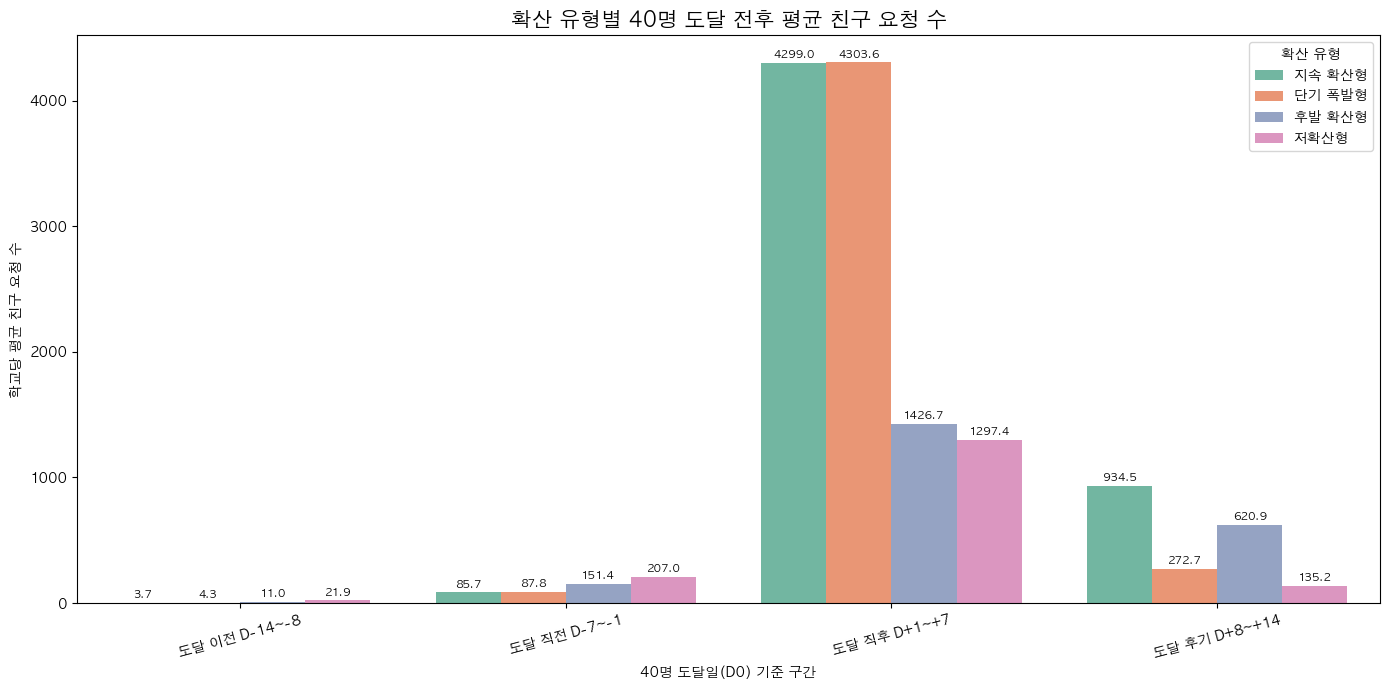

In [22]:
# ============================================================
# 14-6. 확산 유형별 평균 친구 요청 수
# ============================================================

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=type_request_summary_clean,
    x="기간",
    y="학교당_평균친구요청",
    hue="확산유형",
    hue_order=type_order,
    palette="Set2"
)

plt.title(
    "확산 유형별 40명 도달 전후 평균 친구 요청 수",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("40명 도달일(D0) 기준 구간")
plt.ylabel("학교당 평균 친구 요청 수")
plt.xticks(rotation=15)
plt.legend(title="확산 유형")

# 막대 위 수치 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

# 유형별 친구 요청 수락률

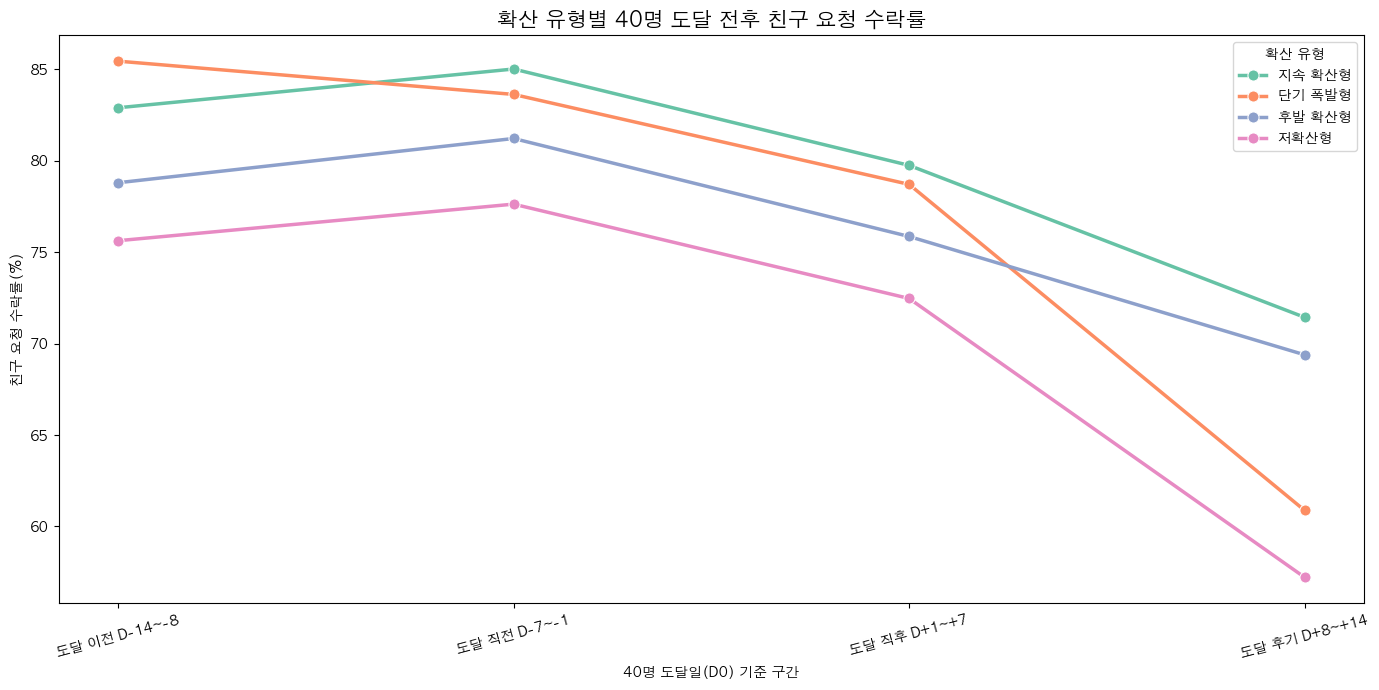

In [23]:
# ============================================================
# 14-7. 확산 유형별 친구 요청 수락률
# ============================================================

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=type_request_summary_clean,
    x="기간",
    y="친구요청수락률(%)",
    hue="확산유형",
    hue_order=type_order,
    marker="o",
    linewidth=2.5,
    markersize=8,
    palette="Set2"
)

plt.title(
    "확산 유형별 40명 도달 전후 친구 요청 수락률",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("40명 도달일(D0) 기준 구간")
plt.ylabel("친구 요청 수락률(%)")
plt.xticks(rotation=15)
plt.legend(title="확산 유형")

plt.tight_layout()
plt.show()

# 유형별 신규 가입자당 친구 요청 수

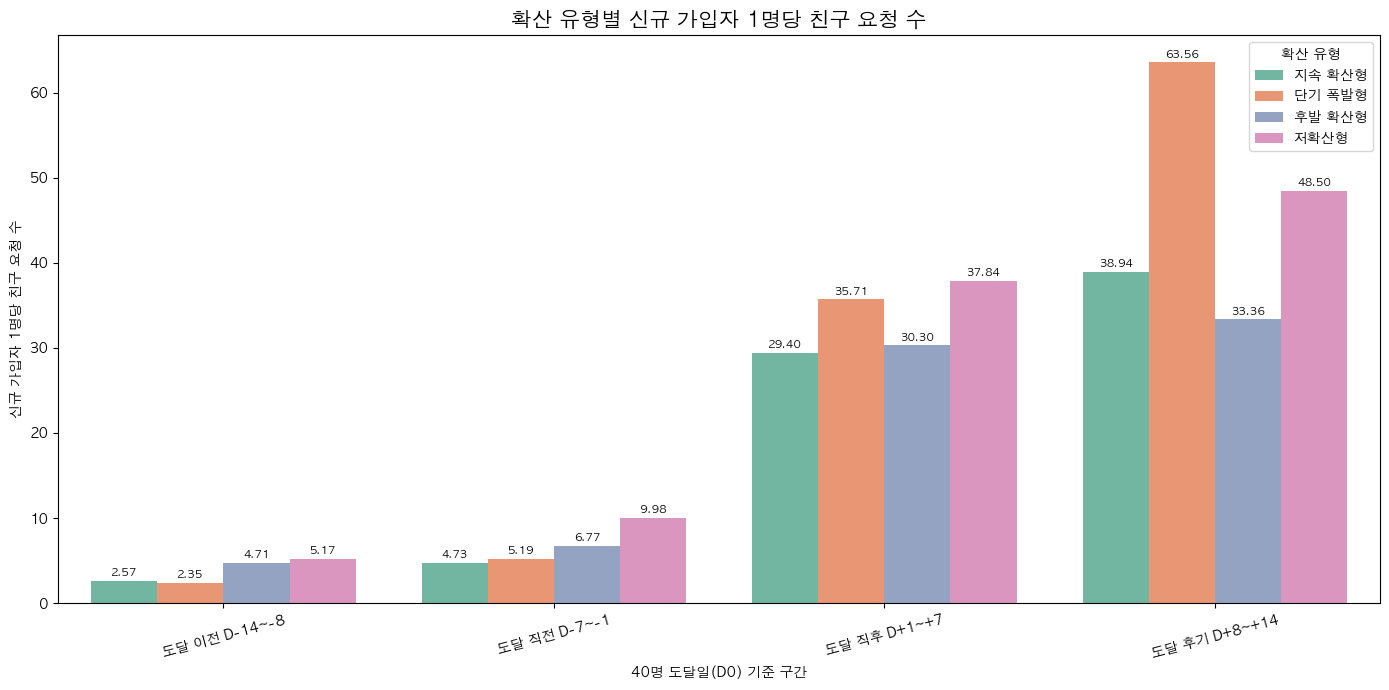

In [24]:
# ============================================================
# 14-8. 확산 유형별 신규 가입자당 친구 요청 수
# ============================================================

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=type_request_summary_clean,
    x="기간",
    y="신규가입자당_친구요청수",
    hue="확산유형",
    hue_order=type_order,
    palette="Set2"
)

plt.title(
    "확산 유형별 신규 가입자 1명당 친구 요청 수",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("40명 도달일(D0) 기준 구간")
plt.ylabel("신규 가입자 1명당 친구 요청 수")
plt.xticks(rotation=15)
plt.legend(title="확산 유형")

# 막대 위 수치 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()